In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_PATH = "../data/raw/synthetic_fraud_dataset.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label,Txn_to_Balance_Pct,Amount_Zscore_User
0,TXN_33553,USER_1834,39.79,POS,14-Aug-23,93213.17,Laptop,Sydney,Travel,0,7,Amex,65,0,0.043,-0.874
1,TXN_9427,USER_7875,1.19,Bank Transfer,07-Jun-23,75725.25,Mobile,New York,Clothing,0,13,Mastercard,186,1,0.002,-1.050
2,TXN_199,USER_2734,28.96,Online,20-Jun-23,1588.96,Tablet,Mumbai,Restaurants,0,14,Visa,226,1,1.823,-0.368
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,07-Dec-23,76807.20,Tablet,New York,Clothing,0,8,Visa,76,1,0.331,1.000
4,TXN_39489,USER_2014,31.28,POS,11-Nov-23,92354.66,Mobile,Mumbai,Electronics,1,14,Mastercard,140,1,0.034,-0.517


In [3]:
df.shape

(50000, 16)

In [4]:
df.columns.tolist()

['Transaction_ID',
 'User_ID',
 'Transaction_Amount',
 'Transaction_Type',
 'Date',
 'Account_Balance',
 'Device_Type',
 'Location',
 'Merchant_Category',
 'Previous_Fraudulent_Activity',
 'Daily_Transaction_Count',
 'Card_Type',
 'Card_Age',
 'Fraud_Label',
 'Txn_to_Balance_Pct',
 'Amount_Zscore_User']

In [5]:
df.dtypes

Transaction_ID                   object
User_ID                          object
Transaction_Amount              float64
Transaction_Type                 object
Date                             object
Account_Balance                 float64
Device_Type                      object
Location                         object
Merchant_Category                object
Previous_Fraudulent_Activity      int64
Daily_Transaction_Count           int64
Card_Type                        object
Card_Age                          int64
Fraud_Label                       int64
Txn_to_Balance_Pct              float64
Amount_Zscore_User              float64
dtype: object

In [6]:
df.isnull().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Date                            0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Card_Type                       0
Card_Age                        0
Fraud_Label                     0
Txn_to_Balance_Pct              0
Amount_Zscore_User              0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df["Transaction_ID"].duplicated().sum()


0

In [9]:
df["Fraud_Label"].value_counts()

Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

In [10]:
df["Fraud_Label"].value_counts(normalize=True) * 100

Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64

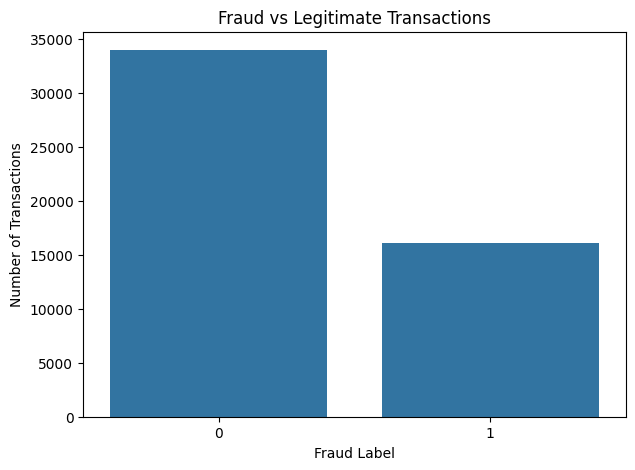

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Fraud_Label"
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud Label")
plt.ylabel("Number of Transactions")

plt.show()

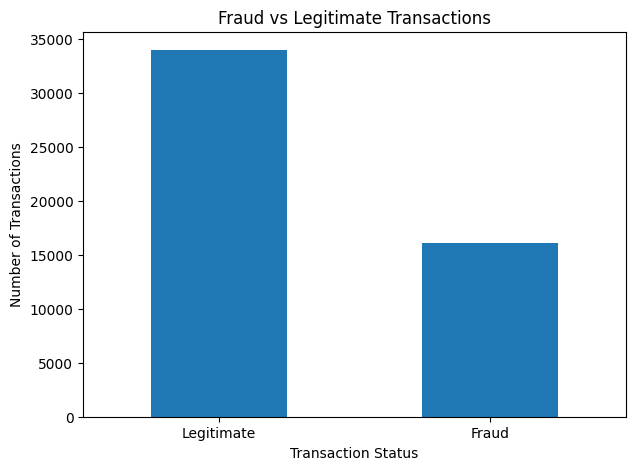

In [12]:
fraud_counts = df["Fraud_Label"].value_counts()

fraud_counts.index = ["Legitimate", "Fraud"]

plt.figure(figsize=(7, 5))

fraud_counts.plot(kind="bar")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)

plt.show()

In [13]:
df["Transaction_Amount"].describe()

count    50000.000000
mean        99.411012
std         98.687292
min          0.000000
25%         28.677500
50%         69.660000
75%        138.852500
max       1174.140000
Name: Transaction_Amount, dtype: float64

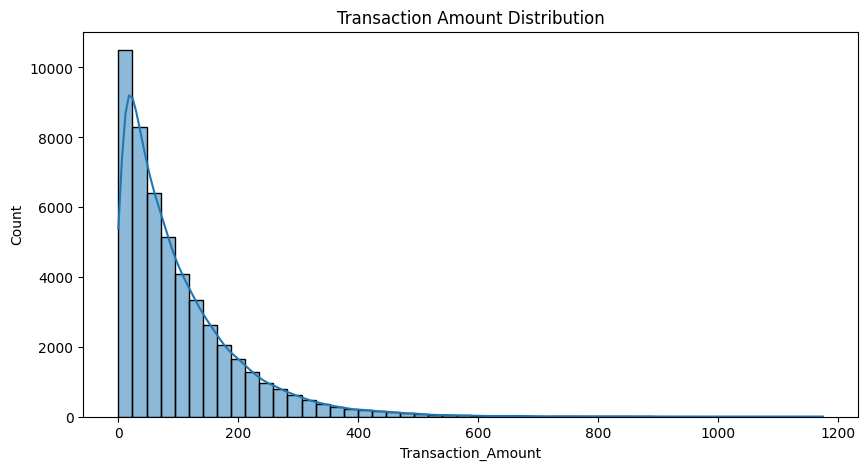

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Transaction_Amount",
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

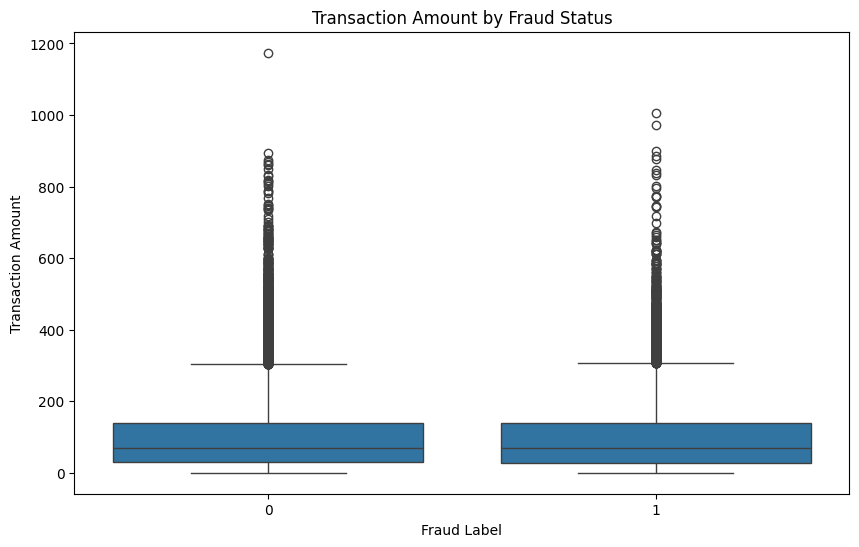

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Fraud_Label",
    y="Transaction_Amount"
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Amount")

plt.show()

In [16]:
pd.crosstab(
    df["Transaction_Type"],
    df["Fraud_Label"]
)

Fraud_Label,0,1
Transaction_Type,,
ATM Withdrawal,8407,4046
Bank Transfer,8457,3995
Online,8515,4031
POS,8554,3995


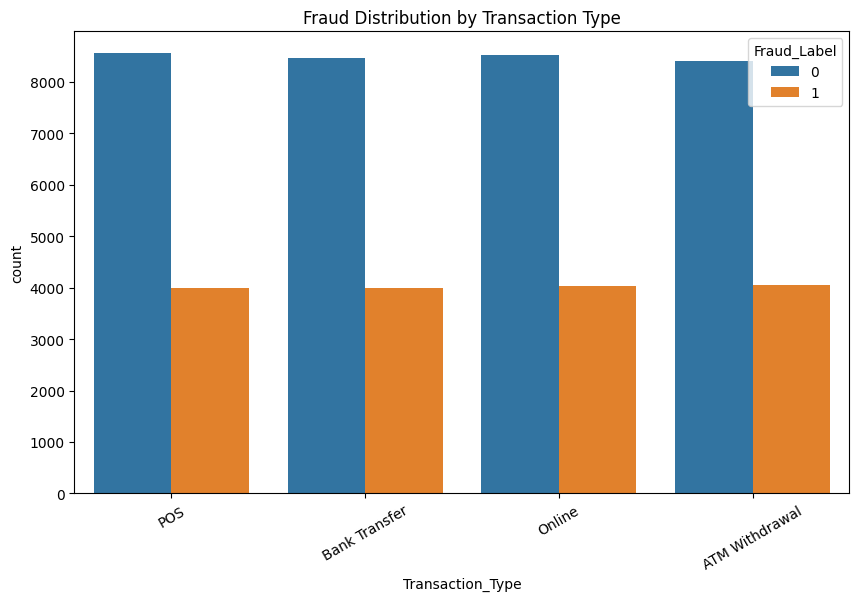

In [17]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Transaction_Type",
    hue="Fraud_Label"
)

plt.title("Fraud Distribution by Transaction Type")

plt.xticks(rotation=30)

plt.show()

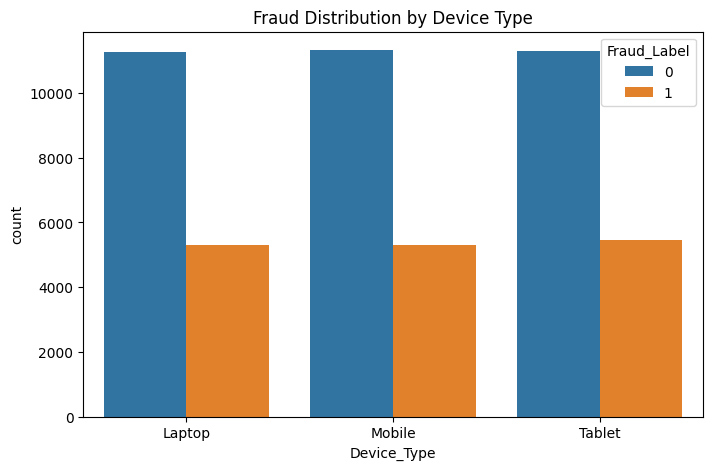

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Device_Type",
    hue="Fraud_Label"
)

plt.title("Fraud Distribution by Device Type")

plt.show()

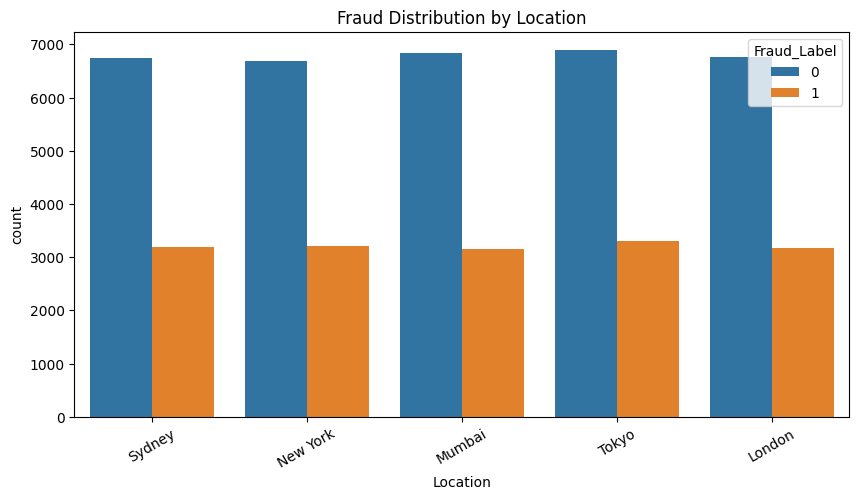

In [19]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Location",
    hue="Fraud_Label"
)

plt.title("Fraud Distribution by Location")

plt.xticks(rotation=30)

plt.show()

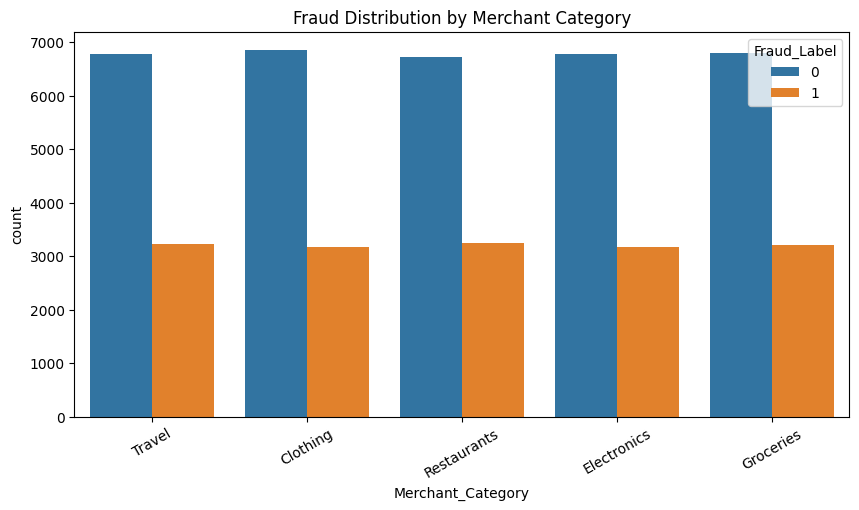

In [20]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Merchant_Category",
    hue="Fraud_Label"
)

plt.title("Fraud Distribution by Merchant Category")

plt.xticks(rotation=30)

plt.show()

In [21]:
pd.crosstab(
    df["Previous_Fraudulent_Activity"],
    df["Fraud_Label"],
    normalize="index"
) * 100

Fraud_Label,0,1
Previous_Fraudulent_Activity,,
0,67.854925,32.145075
1,67.967480,32.032520


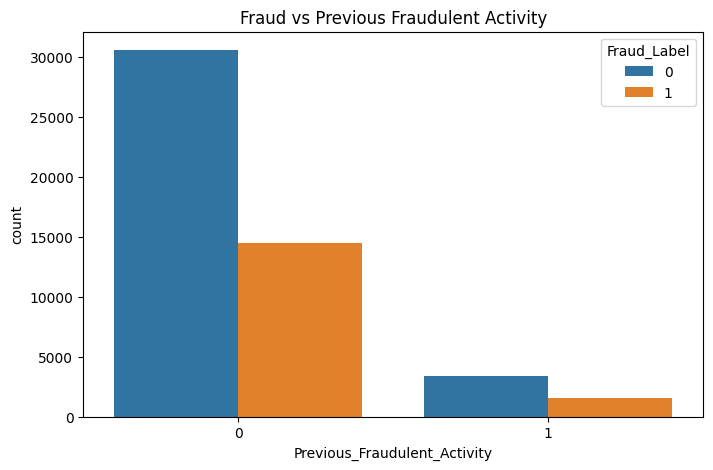

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Previous_Fraudulent_Activity",
    hue="Fraud_Label"
)

plt.title("Fraud vs Previous Fraudulent Activity")

plt.show()

In [23]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%b-%y"
)

In [24]:
df["Date"].min(), df["Date"].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2023-12-31 00:00:00'))

In [25]:
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Day_of_Week"] = df["Date"].dt.dayofweek
df["Day_Name"] = df["Date"].dt.day_name()

In [26]:
daily_fraud = (
    df.groupby("Date")["Fraud_Label"]
    .sum()
    .reset_index()
)

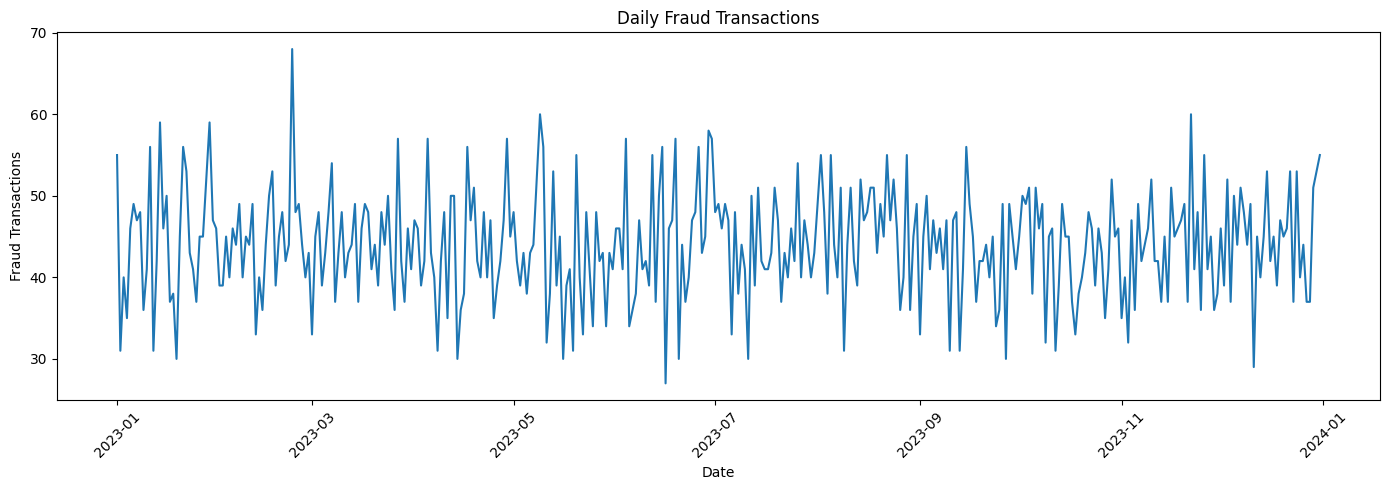

In [27]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_fraud["Date"],
    daily_fraud["Fraud_Label"]
)

plt.title("Daily Fraud Transactions")
plt.xlabel("Date")
plt.ylabel("Fraud Transactions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

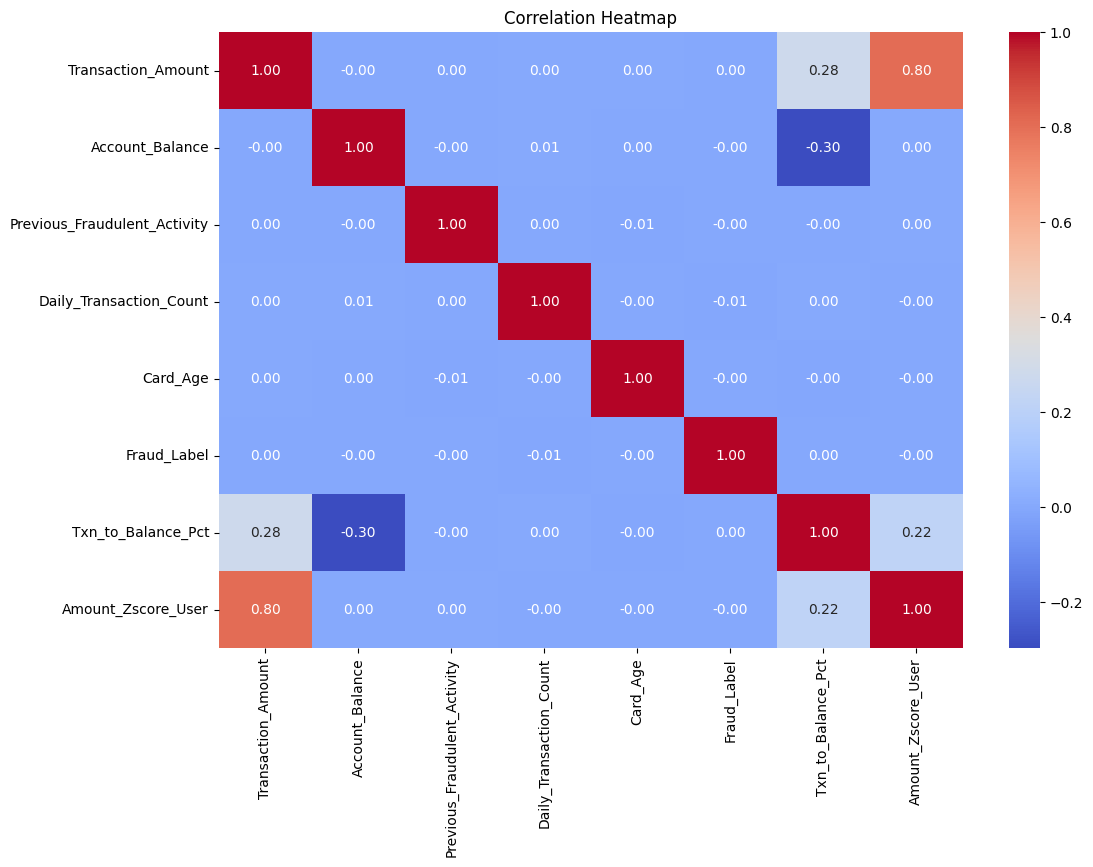

In [28]:
numeric_columns = [
    "Transaction_Amount",
    "Account_Balance",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Card_Age",
    "Fraud_Label",
    "Txn_to_Balance_Pct",
    "Amount_Zscore_User"
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [29]:
processed_df = df.copy()

processed_df.to_csv(
    "../data/processed/fraud_data_initial.csv",
    index=False
)